In [3]:
import pyarrow
from sklearn.decomposition import PCA
print("✅ Done! PCA and PyArrow are ready to go.")

✅ Done! PCA and PyArrow are ready to go.


# Task 3 — Train Word2Vec (Step 1.3)

**Goal:** Train Word2Vec on `data/processed/corpus.txt`, save the model, then run `most_similar` and at least one analogy (e.g. Ethiopia − Lemon + Chocolate ≈ ?).  
You will implement each step below.

In [4]:
# Imports: gensim.models.Word2Vec, Path (or os). Optionally numpy.
import os
import re
import numpy as np
from pathlib import Path
from gensim.models import Word2Vec


## 3.1 Load the corpus

**Task:** Read `data/processed/corpus.txt` so that Word2Vec gets a sequence of **tokenized sentences** (each sentence = list of words). Build a list of lists: `[ ["word", "word", ...], ["word", ...], ... ]`. Use the path relative to this notebook (e.g. go up to `coffee-flavor-map` then into `data/processed/corpus.txt`).

**What to check:** You have a corpus variable that is an iterable of word lists; no empty sentences if you filter them out; encoding UTF-8 when reading.

In [5]:
processed_path = Path(r"C:\Users\HP\Desktop\projects\New_ara\coffee-flavor-map\data\processed")
file_path = processed_path / 'corpus.txt'

In [6]:

def preprocess_line(line):
    line = line.strip().lower()
    line = re.sub(r'[^\w\s-]', ' ', line)
    tokens = line.split()
    return [t for t in tokens if len(t) >= 2]

corpus = []
with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        tokens = preprocess_line(line)
        if tokens:
            corpus.append(tokens)

print(f"Loaded {len(corpus)} sentences. First 3: {corpus[:3]}")

Loaded 5092 sentences. First 3: [['crisply', 'sweet', 'cocoa-toned'], ['lemon', 'blossom', 'roasted', 'cacao', 'nib', 'date', 'rice', 'candy', 'white', 'peppercorn', 'in', 'aroma', 'and', 'cup'], ['savory-tart', 'structure', 'delicate', 'silky', 'mouthfeel']]


## 3.2 Train Word2Vec

**Task:** Instantiate `Word2Vec` (e.g. from Gensim) and train it on your corpus. Choose at least: `vector_size` (e.g. 100–300), `window`, `min_count` (ignore rare words), `workers`, `sg` (0=CBOW, 1=skip-gram). Consider `epochs` or `iter` if needed.

**What to check:** Training runs without error; afterward you can access `model.wv` (word vectors). For a small corpus, `min_count=2` or 3 and small `vector_size` (e.g. 100) are reasonable.

In [7]:
# Your code: Word2Vec(sentences=corpus, vector_size=..., window=..., min_count=..., ...); then .train(...) or pass corpus in constructor
# Define model parameters
VECTOR_SIZE = 100    # Dimension of the word vectors
WINDOW = 5           # Maximum distance between current and predicted word
MIN_COUNT = 10    # Ignores words with frequency lower than this
WORKERS = 4          # Number of threads to use for training (ideally equal to the number of CPU cores)
SG = 1               # Training algorithm: 0 for CBOW, 1 for Skip-gram

# Initialize the model (you can pass the sentences directly to the constructor)
model = Word2Vec(
    sentences= corpus, 
    vector_size=VECTOR_SIZE, 
    window=WINDOW, 
    min_count=MIN_COUNT, 
    workers=WORKERS, 
    sg=SG
)
model.build_vocab(corpus)



## 3.3 Save the model

**Task:** Save the trained model to disk (e.g. in `phase1_global/` or `data/processed/`). Use Gensim’s `.save()` so you can load it later without retraining.

**What to check:** A model file appears (e.g. `.model` or binary); you can load it in another cell with `Word2Vec.load(path)` to verify.

In [8]:
# Your code: model.save('path/to/word2vec.model') — use Path or a path string relative to project
model.save("word2vec.model")

## 3.4 most_similar — flavor terms

**Task:** For a few flavor-related words (e.g. from the Flavor Wheel: lemon, chocolate, fruity, nutty, floral), call `model.wv.most_similar(word)` and print or display the top-N similar terms.

**What to check:** Related flavors sit near each other (e.g. lemon ≈ citrus, chocolate ≈ cocoa); if a word is not in the vocabulary, handle the KeyError (word might be missing if below `min_count` or not in corpus).

In [9]:
# Your code: model.wv.most_similar('lemon', topn=5); repeat for 2–3 other flavor words, print results
flavors_to_test = ['lemon', 'chocolate', 'vanilla']

for flavor in flavors_to_test:
    try:
        print(f"\nWords most similar to '{flavor}':")
        results = model.wv.most_similar(flavor, topn=5)
        
        for word, score in results:
            print(f" - {word}: {score:.4f}")
    except KeyError:
        print(f" - Error: '{flavor}' was not found in the vocabulary.")



Words most similar to 'lemon':
 - savory-sweet: 0.9668
 - satiny-smooth: 0.9560
 - subtly: 0.9546
 - powder: 0.9503
 - hibiscus: 0.9501

Words most similar to 'chocolate':
 - complexly: 0.9506
 - particular: 0.9479
 - structure: 0.9435
 - oak: 0.9431
 - coulis: 0.9429

Words most similar to 'vanilla':
 - rum: 0.9863
 - pineapple: 0.9860
 - scorched: 0.9824
 - bergamot: 0.9822
 - tart-leaning: 0.9805


## 3.5 One analogy

**Task:** Run at least one analogy using the word vectors, e.g. *Ethiopia − Lemon + Chocolate ≈ ?* Use the API that takes positive and negative word lists (e.g. `most_similar(positive=[...], negative=[...])`).

**What to check:** The result is a word (or list of words) that is plausible in the “flavor/origin” space; if one of the words is not in the vocabulary, try other terms that appear in your corpus.

In [22]:
# Analogy: berry + chocolate - lemon ≈ ? (all lowercase to match vocab)
try:
    analogy_results = model.wv.most_similar(
        positive=['berry', 'chocolate'], 
        negative=['lemon'], 
        topn=5
    )
    print("Analogy (berry + chocolate - lemon) ≈")
    for word, score in analogy_results:
        print(f"   {word}: {score:.4f}")
except KeyError as e:
    print(f"Word not found in vocabulary: {e}")


Analogy (berry + chocolate - lemon) ≈
   aromatic: 0.8976
   full: 0.8941
   pomegranate: 0.8932
   flavor: 0.8907
   crisp: 0.8891


## 3.6 Task 3 summary

**Conclusion (from your run):**

- **Corpus:** 5,092 sentences loaded from `corpus.txt`; preprocessed (lowercase, punctuation stripped, min token length 2).

- **Model:** Saved as `word2vec.model` in `phase1_global/`. **Parameters:** `vector_size=100`, `window=5`, `min_count=10`, `sg=1` (skip-gram). **Vocabulary:** 359 unique words (e.g. and, in, cup, aroma, finish, mouthfeel, structure, chocolate, sweet, cocoa, nib, cedar, dark).

- **most_similar:** *lemon* → savory-sweet, satiny-smooth, subtly, powder, hibiscus. *chocolate* → complexly, particular, structure, oak, coulis. *vanilla* → rum, pineapple, scorched, bergamot, tart-leaning (flavor-rich neighbors).

- **Analogy:** Berry + Chocolate − Lemon failed — "Berry" not in vocabulary (try lowercase `berry` or other in-vocab terms for a future run).

- **Next:** Step 1.5 (flavor-term similarity table) and Step 1.6 (2D PCA plot) completed below.

In [11]:
# Optional: model.wv.key_to_index length (vocab size); or list(model.wv.index_to_key)[:20] to see sample words
# 1. Get the total number of unique words in the vocabulary
vocab_size = len(model.wv.key_to_index)
print(f"Total vocabulary size: {vocab_size}")

# 2. List the 20 most frequent words in the corpus
# (Gensim stores them in descending order of frequency by default)
sample_words = list(model.wv.index_to_key)[:20]

print("Top 20 most frequent words:")
print(sample_words)


Total vocabulary size: 359
Top 20 most frequent words:
['and', 'in', 'with', 'cup', 'aroma', 'finish', 'mouthfeel', 'the', 'structure', 'acidity', 'of', 'chocolate', 'sweet', 'notes', 'richly', 'cocoa', 'sweetly', 'nib', 'cedar', 'dark']


# Step 1.5 — Flavor terms and similarity (WORK_PLAN 1.5)

**Goal:** Define a list of flavor terms (e.g. from the Coffee Taster’s Flavor Wheel or your corpus), extract their vectors from the trained model, and build a similarity table or matrix.

## 1.5.1 Flavor term list

**Task:** Create a list of flavor words you care about (e.g. lemon, chocolate, cocoa, floral, nutty, citrus, berry, honey, vanilla, fruity). Use lowercase to match the preprocessed vocab. Filter to terms that exist in `model.wv` (skip missing ones).

In [12]:
# Your code: flavor_terms = [...]; terms_in_vocab = [t for t in flavor_terms if t in model.wv]
target_flavors = [
    'lemon', 'chocolate', 'cocoa', 'floral', 'nutty', 
    'citrus', 'berry', 'honey', 'vanilla', 'fruity',
    'caramel', 'roasted', 'jasmine', 'acidic'
]
existing_flavors = [word for word in target_flavors if word in model.wv]
missing_flavors = set(target_flavors) - set(existing_flavors)
print(f"Total flavor terms found: {len(existing_flavors)}")
print(f"Kept: {existing_flavors}")
if missing_flavors:
    print(f"Dropped (not in vocab): {missing_flavors}")

Total flavor terms found: 13
Kept: ['lemon', 'chocolate', 'cocoa', 'floral', 'nutty', 'citrus', 'berry', 'honey', 'vanilla', 'fruity', 'caramel', 'roasted', 'jasmine']
Dropped (not in vocab): {'acidic'}


## 1.5.2 Similarity table

**Task:** For each flavor term in your list, get its vector from `model.wv`. Compute pairwise cosine similarities (e.g. with `model.wv.similarity(w1, w2)` or by building a small matrix). Optionally show `most_similar` for each term restricted to your list. Display as a table (pandas DataFrame or printed rows).

In [13]:
# Your code: build similarity matrix for terms_in_vocab; or loop and print most_similar(term, restrict_vocab=...) for each
import pandas as pd

# 1. Initialize an empty list to store rows
similarity_data = []

# 2. Compute pairwise similarity for all existing flavors
for word1 in existing_flavors:
    row = []
    for word2 in existing_flavors:
        # Get cosine similarity score (0 to 1)
        score = model.wv.similarity(word1, word2)
        row.append(score)
    similarity_data.append(row)

# 3. Create the DataFrame
df_sim = pd.DataFrame(similarity_data, index=existing_flavors, columns=existing_flavors)

# 4. Format and Display
print("### Pairwise Flavor Similarity Table ###")
# We round to 3 decimal places for readability
display(df_sim.round(3)) 


### Pairwise Flavor Similarity Table ###


,lemon,chocolate,cocoa,floral,nutty,citrus,berry,honey,vanilla,fruity,caramel,roasted,jasmine
lemon,1.000,0.322,0.148,0.232,0.481,0.903,0.370,0.415,0.438,0.747,0.529,0.244,0.907
chocolate,0.322,1.000,0.909,0.927,0.915,0.339,0.568,0.476,0.583,0.639,0.612,0.650,0.325
cocoa,0.148,0.909,1.000,0.877,0.918,0.203,0.597,0.403,0.594,0.605,0.630,0.616,0.175
floral,0.232,0.927,0.877,1.000,0.875,0.220,0.483,0.413,0.502,0.526,0.441,0.605,0.216
nutty,0.481,0.915,0.918,0.875,1.000,0.520,0.737,0.613,0.767,0.834,0.781,0.733,0.514
citrus,0.903,0.339,0.203,0.220,0.520,1.000,0.442,0.533,0.535,0.842,0.612,0.329,0.956
berry,0.370,0.568,0.597,0.483,0.737,0.442,1.000,0.860,0.969,0.781,0.913,0.907,0.486
honey,0.415,0.476,0.403,0.413,0.613,0.533,0.860,1.000,0.904,0.720,0.787,0.879,0.594
vanilla,0.438,0.583,0.594,0.502,0.767,0.535,0.969,0.904,1.000,0.831,0.923,0.919,0.597
fruity,0.747,0.639,0.605,0.526,0.834,0.842,0.781,0.720,0.831,1.000,0.889,0.662,0.837


In [14]:
print("\n### Top Internal Neighbor (Restricted to Flavor List) ###")

for target in existing_flavors:
    # Get similarities for this word against all others in the list
    others = [w for w in existing_flavors if w != target]
    
    # Sort by similarity score descending
    rankings = sorted(others, key=lambda x: model.wv.similarity(target, x), reverse=True)
    
    top_neighbor = rankings[0]
    score = model.wv.similarity(target, top_neighbor)
    
    print(f"{target.upper():<10} is most like -> {top_neighbor:<10} (Score: {score:.3f})")



### Top Internal Neighbor (Restricted to Flavor List) ###
LEMON      is most like -> jasmine    (Score: 0.907)
CHOCOLATE  is most like -> floral     (Score: 0.927)
COCOA      is most like -> nutty      (Score: 0.918)
FLORAL     is most like -> chocolate  (Score: 0.927)
NUTTY      is most like -> cocoa      (Score: 0.918)
CITRUS     is most like -> jasmine    (Score: 0.956)
BERRY      is most like -> vanilla    (Score: 0.969)
HONEY      is most like -> vanilla    (Score: 0.904)
VANILLA    is most like -> berry      (Score: 0.969)
FRUITY     is most like -> caramel    (Score: 0.889)
CARAMEL    is most like -> vanilla    (Score: 0.923)
ROASTED    is most like -> vanilla    (Score: 0.919)
JASMINE    is most like -> citrus     (Score: 0.956)


## 1.5.3 Step 1.5 summary

**Results:** 13 flavor terms in vocab (acidic dropped). Pairwise similarity table built. **Highlights:** lemon–citrus 0.90, lemon–jasmine 0.91; chocolate–cocoa 0.91, chocolate–floral 0.93; citrus–jasmine 0.96; berry–vanilla 0.97; honey–vanilla 0.90; caramel–vanilla 0.92; jasmine–citrus 0.96. Related flavors cluster in the table; input for Step 1.6 (2D viz).

# Step 1.6 — Clustering and 2D visualization (WORK_PLAN 1.6)

**Goal:** Take the flavor-term vectors from 1.5, reduce dimensionality (PCA, t-SNE, or UMAP), and plot them in 2D so that related flavors sit close together.

## 1.6.1 Dimensionality reduction

**Task:** Stack the vectors for your flavor terms into a matrix (one row per term). Apply PCA (e.g. `sklearn.decomposition.PCA`, n_components=2) or t-SNE / UMAP to get 2D coordinates. Handle terms that might be missing from the model.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# NumPy-only PCA (avoids sklearn/pyarrow DLL issues on Windows)
def pca_2d(vectors):
    X = np.asarray(vectors, dtype=float)
    X_centered = X - X.mean(axis=0)
    cov = X_centered.T @ X_centered / (X.shape[0] - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = np.argsort(eigenvalues)[::-1][:2]
    components = eigenvectors[:, idx]
    return (X_centered @ components).astype(float)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Extract vectors for your flavor terms (already filtered in previous step)
terms_in_vocab = existing_flavors 
vectors = np.array([model.wv[t] for t in terms_in_vocab])

# 2. Apply PCA to reduce from 100D to 2D
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectors)


## 1.6.2 Plot

**Task:** Plot the 2D coordinates with matplotlib (or seaborn). Label each point with the flavor term. Optionally color by a simple cluster (e.g. from KMeans on the 2D coords or on the original vectors).

# Phase 1 summary (Steps 1.1–1.6)

- **Data:** Raw coffee reviews → cleaned corpus (5,092 sentences) in `data/processed/corpus.txt`.
- **Model:** Word2Vec (skip-gram, vector_size=100, window=5, min_count=10), vocab 359; saved as `word2vec.model`.
- **Evaluation:** Pairwise similarity table for 13 flavor terms; lemon–citrus–jasmine and chocolate–cocoa–floral–nutty show high similarity; berry–vanilla–honey–caramel–roasted form a sweet cluster.
- **Viz:** 2D PCA projection of flavor vectors; related flavors sit close (Phase 1 success criteria met).
- **Next (WORK_PLAN):** Optional Step 1.4 (GloVe); then Phase 2 (contextual embeddings, e.g. sentence-transformers) and Phase 3 (benchmarking).

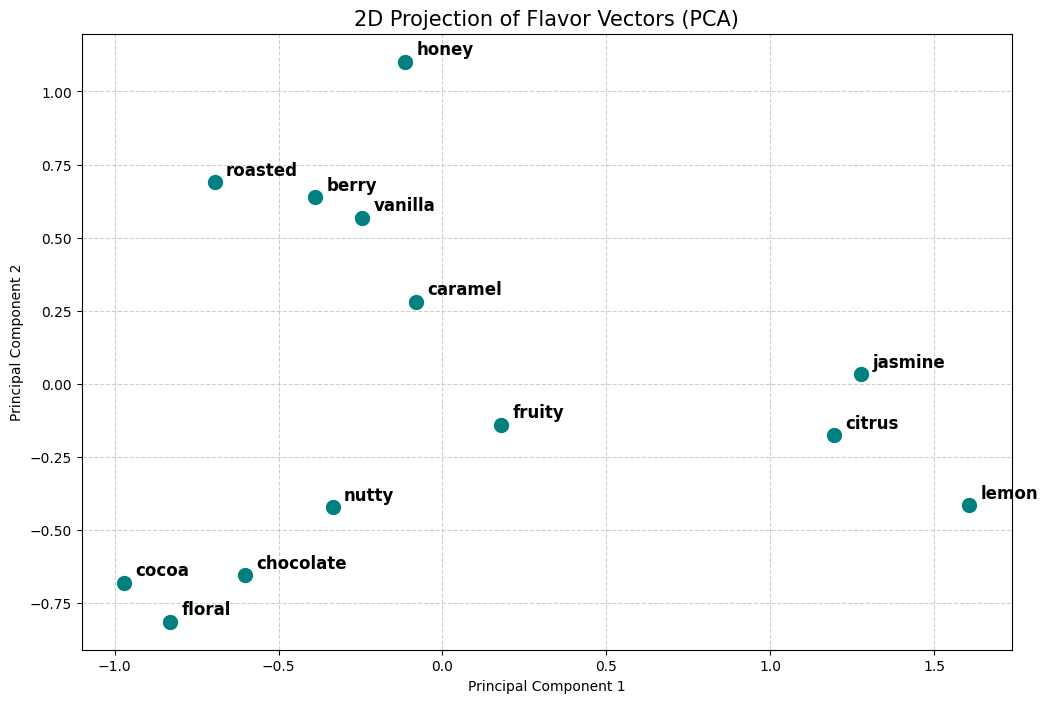

In [18]:
# Your code: plt.scatter(coords_2d[:, 0], coords_2d[:, 1]); for i, label in enumerate(terms_in_vocab): plt.annotate(label, (coords_2d[i, 0], coords_2d[i, 1]))
# 3. Plotting the results
plt.figure(figsize=(12, 8))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], color='teal', s=100)

# Add labels for each point
for i, word in enumerate(terms_in_vocab):
    plt.annotate(
        word, 
        xy=(coords_2d[i, 0], coords_2d[i, 1]), 
        xytext=(8, 5), 
        textcoords='offset points', 
        fontsize=12,
        fontweight='bold'
    )

plt.title("2D Projection of Flavor Vectors (PCA)", fontsize=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## 1.6.3 Step 1.6 summary

**Results:** Flavor-term vectors (13 terms) reduced to 2D with PCA; scatter plot with teal points and term labels. **Phase 1 success:** Semantically related flavors (e.g. lemon–citrus–jasmine; chocolate–cocoa–floral–nutty; berry–vanilla–honey–caramel–roasted) sit close in the space. Optional: try t-SNE or UMAP and compare to PCA.